# Logistic Regression

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [5]:
df=pd.read_csv('candy-data.csv')
df.head()

,competitorname,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,100 Grand,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,3 Musketeers,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,One dime,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,One quarter,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,Air Heads,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465


In [6]:
df.drop('competitorname', axis=1, inplace=True)
df.head()

,chocolate,fruity,caramel,peanutyalmondy,nougat,crispedricewafer,hard,bar,pluribus,sugarpercent,pricepercent,winpercent
0,1,0,1,0,0,1,0,1,0,0.732,0.860,66.971725
1,1,0,0,0,1,0,0,1,0,0.604,0.511,67.602936
2,0,0,0,0,0,0,0,0,0,0.011,0.116,32.261086
3,0,0,0,0,0,0,0,0,0,0.011,0.511,46.116505
4,0,1,0,0,0,0,0,0,0,0.906,0.511,52.341465


In [7]:
training_set,test_set=train_test_split(df,test_size=0.2,random_state=42)

In [9]:
train_df=training_set
test_df=test_set

In [10]:
y_train=train_df['chocolate']
X_train=train_df.drop('chocolate', axis=1)
y_test=test_df['chocolate']
X_test=test_df.drop('chocolate', axis=1)

In [16]:
X_test.shape,y_test.shape,X_train.shape,y_train.shape

((17, 11), (17,), (68, 11), (68,))

In [17]:
y_train.value_counts()

chocolate
0    39
1    29
Name: count, dtype: int64

In [20]:
logreg=LogisticRegression()
logreg.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
y_pred=logreg.predict(X_test)
y_pred

array([0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1])

In [26]:
from sklearn import metrics
cnf_matrix=metrics.confusion_matrix(y_test,y_pred)
cnf_matrix

array([[8, 1],
       [1, 7]])

Text(0.5, 427.9555555555555, 'Predicted label')

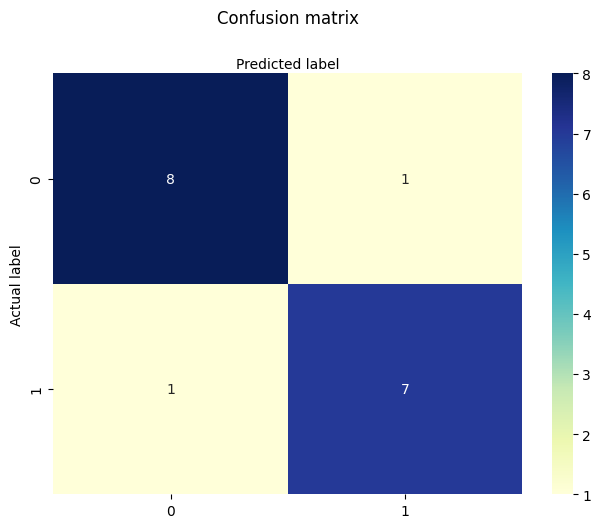

In [29]:
class_names=[0,1]
fig, ax=plt.subplots()
tick_marks=np.arange(len(class_names))
plt.xticks(tick_marks, class_names) 
plt.yticks(tick_marks, class_names)
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

# if i use linear regression in this i'll get decimal values which is not valid for my classification dataset which has either 1 or 0 only

In [30]:
import sklearn.linear_model as lm
model=lm.LinearRegression()
model.fit(X_train,y_train)
y_predict=model.predict(X_test)
y_predict

array([ 0.07319397,  1.01210355,  0.37580013,  0.61582926, -0.22499138,
        0.04514403,  0.52226349,  0.25808782,  0.15500804,  0.25125723,
        0.92148935,  0.84835892,  0.61825747, -0.24701424,  0.07329789,
        0.86062734,  0.853821  ])

In [31]:
mean_squared_error=sk.metrics.mean_squared_error(y_test,y_predict)
mean_squared_error

0.05947311697472262

In [33]:
print('Accuracy:',metrics.accuracy_score(y_test, y_pred)*100)
print('Precision:',metrics.precision_score(y_test, y_pred)*100)
print('Recall:',metrics.recall_score(y_test, y_pred)*100)

Accuracy: 88.23529411764706
Precision: 87.5
Recall: 87.5
